<a href="https://colab.research.google.com/github/carlosmvond/Angelini_et_al_2026/blob/main/fitting_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Model calibration from experimental data

Reproduces **Figure 1** and **Table 1** of *Optimal Switching Time in Inducible
Bioprocesses with Growth and Production Trade-offs*.

**Data.** Batch time courses of biomass, glucose and lactate from anaerobic
*E. coli* fermentations with optogenetic control of ATPase expression
(Espinel-Ríos et al., 2024), under two constant-light conditions: darkness
(non-induced regime $\sigma=1$) and green light at
$524\ \mu\mathrm{mol\,m^{-2}\,s^{-1}}$ (induced regime $\sigma=2$).

**Model.** System (2.1) with $D=0$, Monod kinetics, and $q_\sigma \propto \mu_\sigma$
(growth-associated Luedeking–Piret term).

**Method.** Parameters are estimated independently for each regime by nonlinear
least squares (`lmfit`), integrating with `RK45` and evaluating at the sampling
times. Residuals are normalized by the mean of each dataset so that the three
variables contribute comparably. The half-saturation constant $K_s$ is fixed
rather than fitted: with $K_s \ll S_0$ the Monod term stays saturated throughout,
so $K_s$ is not identifiable from these data (Holmberg, 1982).

**Output.** Fitted parameters (Table 1), a three-panel comparison of data and
fits exported as EPS (Figure 1), and $R^2$ per variable and condition.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.7/97.7 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 4.1 MB/s eta 0:00:00

===== Fit: no light =====
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 67
    # data points      = 27
    # variables        = 5
    chi-square         = 0.16233524
    reduced chi-square = 0.00737887
    Akaike info crit   = -128.076071
    Bayesian info crit = -121.596887
[[Variables]]
    mu_max:  0.21842703 +/- 0.01291837 (5.91%) (init = 0.2)
    K_s:     0.1 (fixed)
    Y:       0.07112357 +/- 0.00522557 (7.35%) (init = 0.1)
    X0:      0.05874091 +/- 0.00469237 (7.99%) (init = 0.07)
    S0:      3.63452117 +/- 0.10388712 (2.86%) (init = 3.71)
    P0:      0.02 (fixed)
    q_max:   2.67671730 +/- 0.11322650 (4.23%) (init = 2)
[[Correlations]] (unreported correlations are < 0.100)
    C(mu_max, X0)    = -0.9435
    C(X0, q_max)     = -0.7606
    C(Y, S0)         = -0.6910
    C(mu_max, q_max) = 

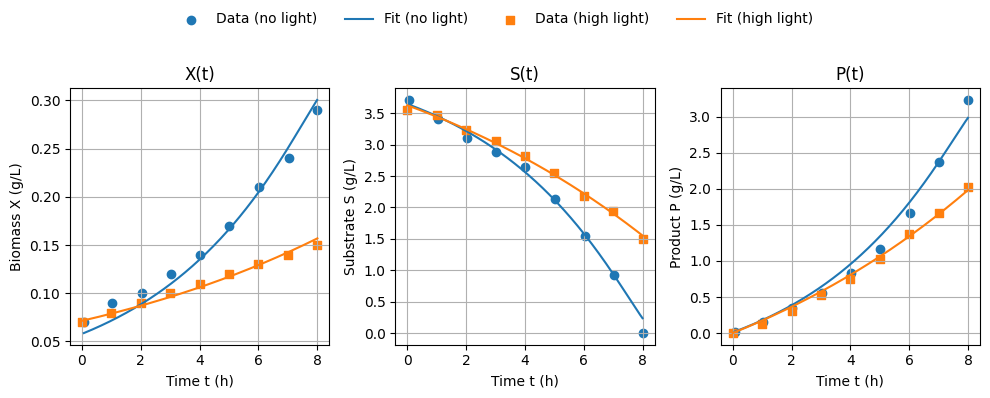

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


===== R2: no light =====
  R2(X) = 0.9783
  R2(S) = 0.9930
  R2(P) = 0.9849

===== R2: high light =====
  R2(X) = 0.9828
  R2(S) = 0.9958
  R2(P) = 0.9958


(np.float64(0.982754414816613),
 np.float64(0.9957865575735497),
 np.float64(0.9957916093556827))

In [2]:
!pip install lmfit
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import lmfit

# ============================================================
# Data
# ============================================================
# Case without light (non-induced regime, sigma = 1)
t_nl = np.array([0.07, 1.03, 2.03, 3.02, 4.01, 5.01, 6.03, 7.02, 7.99])
x_nl = np.array([0.07, 0.09, 0.10, 0.12, 0.14, 0.17, 0.21, 0.24, 0.29])
S_nl = np.array([3.71, 3.40, 3.11, 2.88, 2.65, 2.14, 1.55, 0.93, 0.00])
P_nl = np.array([0.02, 0.15, 0.35, 0.56, 0.83, 1.17, 1.67, 2.37, 3.23])

# Case with high light (induced regime, sigma = 2)
t_hl = np.array([0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0])
x_hl = np.array([0.07, 0.08, 0.09, 0.10, 0.11, 0.12, 0.13, 0.14, 0.15])
S_hl = np.array([3.55, 3.47, 3.24, 3.06, 2.82, 2.55, 2.18, 1.94, 1.49])
P_hl = np.array([0.0, 0.12, 0.30, 0.53, 0.75, 1.02, 1.37, 1.66, 2.03])

# ============================================================
# Model: system (2.1) with D = 0
#   dX/dt = mu(S) X
#   dS/dt = -mu(S) X / Y
#   dP/dt = q(S) X
# with mu(S) = mu_max S/(K_s+S) and q(S) = q_max S/(K_s+S)
# ============================================================
def model_monod(t, y, mu_max, K_s, Y, q_max):
    X, S, P = y
    monod = S / (K_s + S)
    mu = mu_max * monod
    q = q_max * monod
    dXdt = mu * X
    dSdt = -(1.0 / Y) * mu * X
    dPdt = q * X
    return [dXdt, dSdt, dPdt]


def make_residual(t_data, x_data, S_data, P_data):
    def residual(params):
        mu_max = params["mu_max"].value
        K_s    = params["K_s"].value
        Y      = params["Y"].value
        q_max  = params["q_max"].value
        X0     = params["X0"].value
        S0     = params["S0"].value
        P0     = params["P0"].value

        sol = solve_ivp(
            fun=model_monod,
            t_span=(t_data[0], t_data[-1]),
            y0=[X0, S0, P0],
            t_eval=t_data,
            method="RK45",
            atol=1e-8, rtol=1e-6,
            args=(mu_max, K_s, Y, q_max),
        )

        x_model, S_model, P_model = sol.y[0], sol.y[1], sol.y[2]

        res_x = (x_model - x_data) / np.mean(x_data)
        res_S = (S_model - S_data) / np.mean(S_data)
        res_P = (P_model - P_data) / np.mean(P_data)

        return np.r_[res_x, res_S, res_P]

    return residual


def fit_case(t_data, x_data, S_data, P_data, Ks_value, S0_bounds, mu_bounds=(0, 0.5)):
    params = lmfit.Parameters()
    params.add("mu_max", value=0.2, min=mu_bounds[0], max=mu_bounds[1])
    params.add("K_s",    value=Ks_value, min=0, max=10.0, vary=False)
    params.add("Y",      value=0.1, min=0, max=1.0)
    params.add("X0",     value=x_data[0], min=0.5*x_data[0], max=1.5*x_data[0])
    params.add("S0",     value=S_data[0], min=S0_bounds[0]*S_data[0], max=S0_bounds[1]*S_data[0])
    params.add("P0",     value=P_data[0], vary=False)
    params.add("q_max",  value=2.0, min=0, max=10.0)

    resid = make_residual(t_data, x_data, S_data, P_data)
    minimizer = lmfit.Minimizer(lambda p: resid(p), params)
    return minimizer.minimize(method="leastsq")


def simulate_fit(result, t0, tf, n=300):
    p = result.params
    t_fit = np.linspace(t0, tf, n)
    sol_fit = solve_ivp(
        fun=model_monod,
        t_span=(t_fit[0], t_fit[-1]),
        y0=[p["X0"].value, p["S0"].value, p["P0"].value],
        t_eval=t_fit,
        method="RK45",
        atol=1e-8, rtol=1e-6,
        args=(p["mu_max"].value, p["K_s"].value, p["Y"].value, p["q_max"].value),
    )
    return t_fit, sol_fit.y[0], sol_fit.y[1], sol_fit.y[2]


# ============================================================
# Fit both cases
# ============================================================
K_S = 0.10   # fixed, identical in both regimes (Assumption 3)

res_nl = fit_case(t_nl, x_nl, S_nl, P_nl, Ks_value=K_S, S0_bounds=(0.95, 1.05))
res_hl = fit_case(t_hl, x_hl, S_hl, P_hl, Ks_value=K_S, S0_bounds=(0.85, 1.15))

for res, label in [(res_nl, "no light"), (res_hl, "high light")]:
    print(f"\n===== Fit: {label} =====")
    lmfit.report_fit(res)
    # Y_{P/S} = q_max Y / mu_max  (product yield on substrate)
    Y_PS = res.params["q_max"].value * res.params["Y"].value / res.params["mu_max"].value
    print(f"Y_P/S = q_max*Y/mu_max = {Y_PS:.4f}")

# Smooth curves
t_fit_nl, X_fit_nl, S_fit_nl, P_fit_nl = simulate_fit(res_nl, t_nl[0], t_nl[-1])
t_fit_hl, X_fit_hl, S_fit_hl, P_fit_hl = simulate_fit(res_hl, t_hl[0], t_hl[-1])

# ============================================================
# Figure: three horizontal panels
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(10, 4))

panels = [
    (axes[0], x_nl, X_fit_nl, x_hl, X_fit_hl, "Biomass X (g/L)", "X(t)"),
    (axes[1], S_nl, S_fit_nl, S_hl, S_fit_hl, "Substrate S (g/L)", "S(t)"),
    (axes[2], P_nl, P_fit_nl, P_hl, P_fit_hl, "Product P (g/L)", "P(t)"),
]

for ax, d_nl, f_nl, d_hl, f_hl, ylabel, title in panels:
    ax.scatter(t_nl, d_nl, label="Data (no light)", marker="o")
    ax.plot(t_fit_nl, f_nl, label="Fit (no light)")
    ax.scatter(t_hl, d_hl, label="Data (high light)", marker="s")
    ax.plot(t_fit_hl, f_hl, label="Fit (high light)")
    ax.set_xlabel("Time t (h)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4, frameon=False)
plt.tight_layout(rect=[0, 0, 1, 0.88])
plt.show()

# ============================================================
# Export EPS (download only works in Colab)
# ============================================================
eps_name = "fit_comparison_switch.eps"
fig.savefig(eps_name, format="eps", bbox_inches="tight")

try:
    from google.colab import files
    files.download(eps_name)
except ImportError:
    print(f"Figure saved as {eps_name}")


# ============================================================
# Goodness of fit
# ============================================================
def r_squared(y_data, y_model):
    """R2 = 1 - SS_res/SS_tot, using the data mean as reference."""
    y_data, y_model = np.asarray(y_data), np.asarray(y_model)
    ss_res = np.sum((y_data - y_model) ** 2)
    ss_tot = np.sum((y_data - np.mean(y_data)) ** 2)
    return 1.0 - ss_res / ss_tot


def r2_report(result, t_data, x_data, S_data, P_data, label=""):
    """Evaluate the model at the sampling times and report R2 per variable."""
    p = result.params
    sol = solve_ivp(
        fun=model_monod,
        t_span=(t_data[0], t_data[-1]),
        y0=[p["X0"].value, p["S0"].value, p["P0"].value],
        t_eval=t_data,
        method="RK45",
        atol=1e-8, rtol=1e-6,
        args=(p["mu_max"].value, p["K_s"].value, p["Y"].value, p["q_max"].value),
    )
    r2 = [r_squared(d, m) for d, m in zip((x_data, S_data, P_data), sol.y)]
    print(f"\n===== R2: {label} =====")
    for name, val in zip("XSP", r2):
        print(f"  R2({name}) = {val:.4f}")
    return tuple(r2)


r2_report(res_nl, t_nl, x_nl, S_nl, P_nl, label="no light")
r2_report(res_hl, t_hl, x_hl, S_hl, P_hl, label="high light")